# 特征工程

本部分笔记用于选择哪些特征作为加载进深度学习模型的资料

在 NASA 电池数据集中，直接将单个循环（Cycle）内几百个高频采样点作为时间序列丢给深度学习模型，往往会遭遇严重的维度灾难并吸入大量噪声。
因此，业界和学术界的标准操作（Feature Engineering）是：从每一个循环内的物理变化曲线中提取出能反映**老化退化机制**的抽象标量，我们统称为 **健康因子（Health Indicators, HIs）**。

### 推荐选取的输入特征（核心健康因子）

结合锂电池的衰降物理学（极化增加、内阻升高、活性物质损耗），我强烈建议提取以下 **4个核心指标** 作为模型的输入列，以配合真实的 `Capacity` 标签进行序列预测：

#### 1. 恒流放电时间 (CC Discharge Time)
*   **物理意义**：随着电池活性锂离子的损失，电池在 `2A` 恒流放电下的支撑时间会越来越短，这就直接反映了储电能力的衰减。
*   **数学提取**：本次循环中，时间序列差的跨度，即 $t_{end} - t_{start}$。

#### 2. 等效电压下降时间段 (Time of Equivalent Voltage Drop)
*   **物理意义**：电池老化会导致欧姆内阻和极化内阻急剧增加，放电平台（电压相对平稳的区域）会缩短并快速跌落低电位。因此寻找一段等效的电压窗口（例如从 `3.8V` 降至 `3.4V`），记录穿越这个区间所花费的时间。老化的电池花费的时间会呈断崖式缩减。
*   **数学提取**：$T_{drop} = t(V \le 3.4) - t(V \le 3.8)$。

#### 3. 最高表面温度响应 (Peak Response Temperature)
*   **物理意义**：电池内阻增大不仅意味着电量衰减，还会导致放热功率激增（焦耳定律 $Q = I^2 R t$ 及多重老化的副反应）。随着循环加深，每次放电测得的表面最高温度往往呈现爬升趋势。
*   **数学提取**：寻找本次放电循环内温度传感器的最大值 $\max(T_{measured})$。

#### 4. 放电面积/总释放能量评价 (Discharge Energy Integral)
*   **物理意义**：由于后期平台电压整体降低，其总输出能量实际上衰减得比额定容量（Ah）还要快。电压乘以电流关于时间的积分可以精准捕捉这个由于电压下降导致的能量缩水现象。
*   **数学提取**：对 V-t 和 I-t 曲线求梯形积分近似（$E = \int V \cdot (-I) \, dt$）。



## 4个特征的验证

正在加载测试数据: B0005_cleaned.pkl ...
成功提取了 168 个循环的 4 项健康因子(HIs)。

计算特征之间的相关性分布：


C:\Users\PLUTO\AppData\Local\Temp\ipykernel_13500\1220817001.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_integral = np.trapz(y=power_arr, x=time_arr)


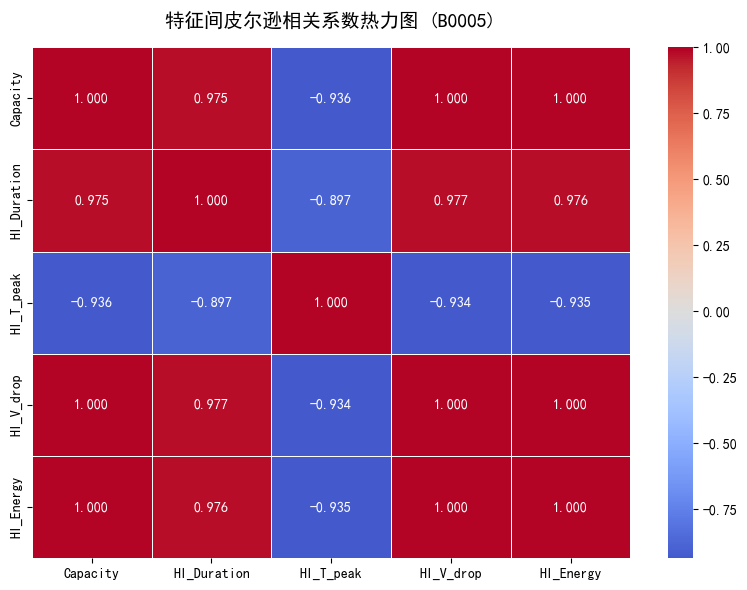

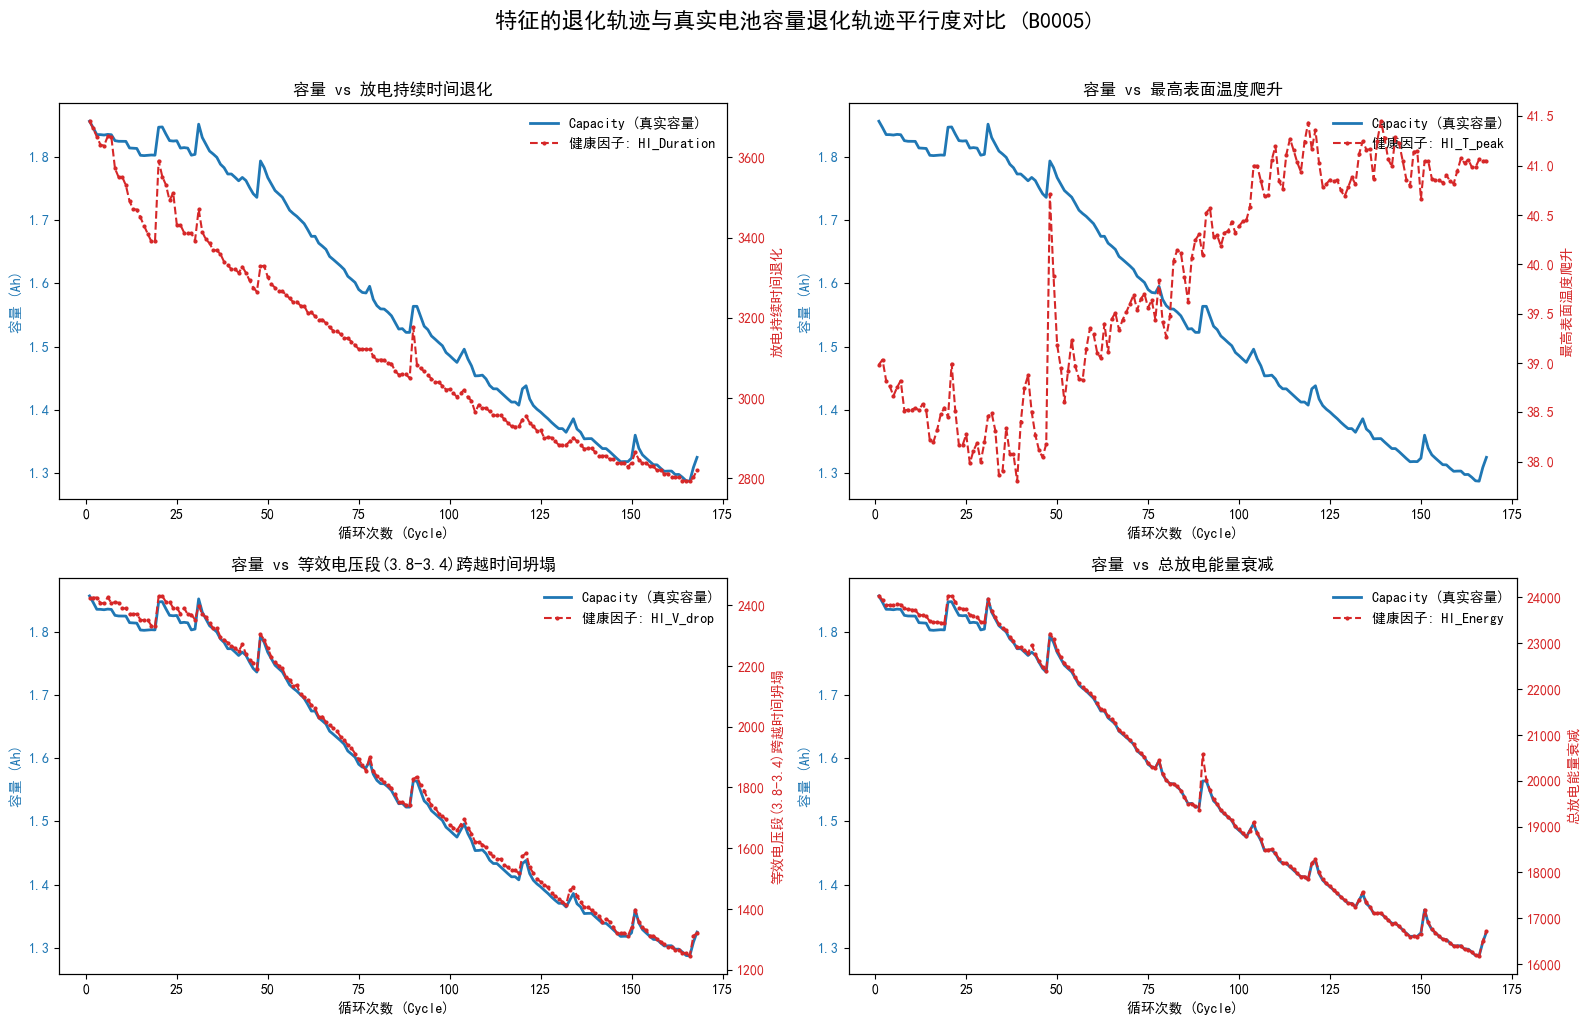

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr

# 配置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 我们从 G1 组中选取具有经典退化特性的 B0005 作为验证样例
TEST_BATTERY_PATH = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G1\B0005_cleaned.pkl")

print(f"正在加载测试数据: {TEST_BATTERY_PATH.name} ...")
df_b0005 = pd.read_pickle(TEST_BATTERY_PATH)

# 用于存储提取出来的特征序列
features_record = []

# ====================================================
# 核心特征提取循环
# ====================================================
for idx, row in df_b0005.iterrows():
    cycle_idx = row['Cycle_Index']
    capacity = row['Capacity']
    
    time_arr = row['Time']
    v_arr = row['Voltage_measured']
    i_arr = row['Current_measured']
    t_arr = row['Temperature_measured']
    
    # -------- 1. 恒流放电时间 (duration) --------
    if len(time_arr) > 0:
        duration = time_arr[-1] - time_arr[0]
    else:
        duration = np.nan
        
    # -------- 2. 放电最高温度 (T_peak) --------
    if len(t_arr) > 0:
        t_peak = np.nanmax(t_arr)
    else:
        t_peak = np.nan
        
    # -------- 3. 等效电压下降时间段 (v_drop_time) --------
    # 选取放电平台期的一段典型压降，例如 3.8V 到 3.4V
    v_drop_time = np.nan
    v_high, v_low = 3.8, 3.4
    if len(v_arr) > 0 and len(time_arr) > 0:
        # 寻找第一次低于 v_high 的充放电节点
        idx_high_arr = np.where(v_arr <= v_high)[0]
        # 寻找第一次低于 v_low 的充放电节点
        idx_low_arr = np.where(v_arr <= v_low)[0]
        
        if len(idx_high_arr) > 0 and len(idx_low_arr) > 0:
            idx_high = idx_high_arr[0]
            idx_low = idx_low_arr[0]
            if idx_low > idx_high:
                v_drop_time = time_arr[idx_low] - time_arr[idx_high]
                
    # -------- 4. 放电总能量 / 面积 (energy_integral) --------
    # E = ∫ V * I dt，由于放电电流是负数，所以我们计算 ∫ V * (-I) dt
    energy_integral = np.nan
    if len(v_arr) > 1 and len(i_arr) > 1 and len(time_arr) > 1:
        # 使用 numpy.trapz 进行数值积分
        # 注意清洗时我们将极个别异常值设为了NaN并且插值了，这确保了数组长度对齐且合法
        power_arr = v_arr * np.abs(i_arr) 
        energy_integral = np.trapz(y=power_arr, x=time_arr)
        
        
    # 记录本 Cycle 的结果
    features_record.append({
        'Cycle': cycle_idx,
        'Capacity': capacity,
        'HI_Duration': duration,
        'HI_T_peak': t_peak,
        'HI_V_drop': v_drop_time,
        'HI_Energy': energy_integral
    })

# 转化为 DataFrame 方便分析
df_hi = pd.DataFrame(features_record)
# 暂时丢除极具个别可能因为积分或寻找阈值失败得到的 NaN（一般发生在测试完全断电崩溃的极少数回合）
df_hi = df_hi.dropna()

print(f"成功提取了 {len(df_hi)} 个循环的 4 项健康因子(HIs)。")

# ====================================================
# 计算皮尔逊相关系数 (Pearson Correlation) 与 相关性热力图可视化
# ====================================================
# 验证提取的 HI 是否与真实的退化趋势（Capacity）存在高度绑定关系
print("\n计算特征之间的相关性分布：")
corr_matrix = df_hi[['Capacity', 'HI_Duration', 'HI_T_peak', 'HI_V_drop', 'HI_Energy']].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5, center=0)
plt.title(f'特征间皮尔逊相关系数热力图 (B0005)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ====================================================
# 绘制多子图：特征衰退与容量退化的直观时序对比
# 使用由于量纲不同而采用双Y轴绘制
# ====================================================
features_to_plot = ['HI_Duration', 'HI_T_peak', 'HI_V_drop', 'HI_Energy']
titles = ['放电持续时间退化', '最高表面温度爬升', '等效电压段(3.8-3.4)跨越时间坍塌', '总放电能量衰减']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
cycles = df_hi['Cycle']
capacity = df_hi['Capacity']

for i, (feat, title) in enumerate(zip(features_to_plot, titles)):
    ax1 = axes[i]
    color1 = 'tab:blue'
    ax1.set_xlabel('循环次数 (Cycle)')
    ax1.set_ylabel(f'容量 (Ah)', color=color1)
    line1, = ax1.plot(cycles, capacity, color=color1, label='Capacity (真实容量)', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # 实例化共享相同 x 轴的第二个 axes
    ax2 = ax1.twinx()  
    color2 = 'tab:red'
    ax2.set_ylabel(title, color=color2) 
    line2, = ax2.plot(cycles, df_hi[feat], color=color2, linestyle='--', marker='.', markersize=4, label=f'健康因子: {feat}')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    ax1.set_title(f"容量 vs {title}", fontsize=12, fontweight='bold')
    
    # 合并图例
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', frameon=False)
    
plt.suptitle('特征的退化轨迹与真实电池容量退化轨迹平行度对比 (B0005)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 特征相关性分析与结论

通过上述皮尔逊相关系数矩阵（Pearson Correlation Coefficient）的双轴对比折线图，可以对这四个健康因子（HI）进行严谨的模型可用性评估与物理意义解释：

#### 1. 电压降与能量特征 (`HI_V_drop` & `HI_Energy`): 极强正相关 (+1.000)
**现象观测**：
等效电压段（3.8V-3.4V）放电时长与总放电能量几乎与真实容量退化轨迹完美重合。
**物理机理**：
*   在恒流（CC）放电且有着固定截止电压的实验下，**放电能量（Power积分）和容量（Current积分）本就是在严密的物理公式体系下锚定的**，因此呈完美相关可以作为寿命预测的硬基准代理。
*   3.8V-3.4V 这个“等效电压下降时长”特征避开了放电极化最为严重的前后两端（通常充满电开始放时的极化与即将耗尽时的极化极为剧烈且充满非线性噪声），截取中间放电平台，完美地揭示了**可用活性锂离子 (LAM)** 的损失导致的平台支撑时长缩水。

#### 2. 全局放电时长 (`HI_Duration`): 高度正相关 (+0.975)
**现象观测**：
它高度贴合容量衰退，但早期存在非常细小的偏差。
**物理机理**：
因为在电池的整个退化周期早期，存在固态电解质膜（SEI）生成的化成激活以及所谓的“容量回升效应（Regeneration）”。并且因为把最终阶段电压“骤跌”阶段算入了时长，增加了几分非线性干扰。这同样是一个非常优秀的代理特征。

#### 3. 峰值温度 (`HI_T_peak`): 极强负相关 (-0.936)
**现象观测**：
随着电池容量下跌，电池在放电过程中达到的表面最高温度随之爬升。不过，这个信号的折线图（右上方图表）肉眼可见存在大量的“锯齿状高频波动”。
**物理机理**：
在恒定的 2A 放电下，老化导致**欧姆内阻和极化内阻（Internal Resistance）越来越大**，依据焦耳定律 $Q=I^2Rt$，电池必然产热加剧，导致温度不断上升。
然而，热学信号容易受外部环境（例如 NASA 的测试温箱空调波动、探头细微贴合偏差等）扰动。

--- 

### 💡 对深度学习建模（LSTM/Transformer）的下一步启示
1. **防范多重共线性**：`HI_V_drop` 和 `HI_Energy` 相关性完美重合，直接丢给 LSTM 可能会导致参数冗余和过拟合特定工况。在接下来的深度学习实验中，我们可以把它们都输入，但在消融实验时应对比“多特征是否真的好于单特征”。
2. **需要进行温度平滑操作**：针对 `HI_T_peak` 那种上下剧烈震荡的锯齿信号，LSTM 会在通过各类隐态门（Forget/Input Gates）时非常敏感，经常为了捕捉那些其实是没有老化意义的噪声而乱调权重。在接下来的构建输入张量（Tensor）时，我们应该引入类似**滑动平均（Moving Average）**或 **Savitzky-Golay 平滑滤波** 先剥离它表面的高频毛刺，再送入模型。

基于以上内容，我们开始打包训练用的数据。

## 训练数据打包

在正式写代码进行特征构建落盘前，我们将采取以下结构化的打包策略，以完全符合现代深度学习以及时序预测的规范：

1. **跨组别自动化遍历与提取**：建立一个封装好的提取函数，遍历清洗完毕的 `data/cleaned/` 下的 `G1`, `G3`, `G9` 文件夹下的所有电池。把每一个 `Cycle` 转化为只包含提取后抽象标量（我们上方找出来的 4 个 HI 和真实 Capacity）的一行记录。
2. **信号平滑（Savitzky-Golay 滤波器）**：针对结论中指出的 `HI_T_peak` 噪声问题，我们将采用 Savitzky-Golay 滤波器。选择它的原因在于它能在执行滑动窗口平滑时**极好地保留信号特征（如剧烈拐点）极小化相位延迟**，这比普通的均值滤波在物理意义上要强上很多（很适合放在论文“去噪干预”章节进行单独阐述）。
3. **二维表格化落盘 (Tabular Storage)**：坚决**不在**这一步急于切片打包成形状类似 `(Batch_Size, Seq_Len, Features)` 的 PyTorch 张量。因为时序切片高度依赖我们未来对于历史序列长度的超参数假定。现在，我们需要把规整化的全局数据集存为一个干净的 CSV 或 Pickle 的表格态，保存在新分配的 `data/features` 目录下。

接下来，我们就编写代码贯彻这一打包逻辑。

======= 开始跨组别提取健康因子 =======
[G1 - B0005] 提取完毕! 有效 Cycle 数: 168
[G1 - B0006] 提取完毕! 有效 Cycle 数: 168
[G1 - B0007] 提取完毕! 有效 Cycle 数: 168
[G1 - B0018] 提取完毕! 有效 Cycle 数: 132
[G3 - B0029] 提取完毕! 有效 Cycle 数: 40
[G3 - B0030] 提取完毕! 有效 Cycle 数: 40
[G3 - B0031] 提取完毕! 有效 Cycle 数: 40
[G3 - B0032] 提取完毕! 有效 Cycle 数: 40
[G9 - B0053] 提取完毕! 有效 Cycle 数: 55
[G9 - B0054] 提取完毕! 有效 Cycle 数: 101
[G9 - B0055] 提取完毕! 有效 Cycle 数: 101
[G9 - B0056] 提取完毕! 有效 Cycle 数: 101

======= 开始应用 Savitzky-Golay 滤波器平滑热力学噪声 =======


C:\Users\PLUTO\AppData\Local\Temp\ipykernel_13500\2663533869.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(y=p_arr, x=time_arr)
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_13500\2663533869.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(y=p_arr, x=time_arr)
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_13500\2663533869.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(y=p_arr, x=time_arr)
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_13500\2663533869.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(y=p_arr, x=time_arr)
C:\Users\PLUTO\AppDa

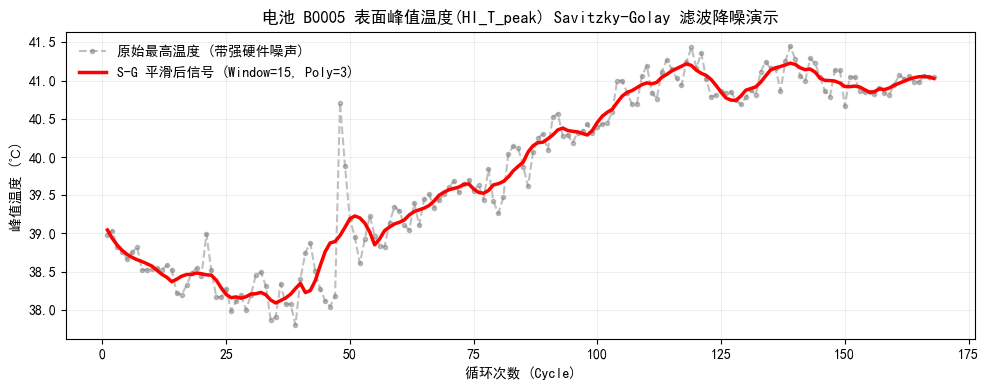


🎉 完美收官! 所有电池的降维特征已打包落盘。
总计行数: 1154
数据存放位置:
  - C:\Users\PLUTO\Desktop\battery-rul\data\features\all_batteries_features.csv
  - C:\Users\PLUTO\Desktop\battery-rul\data\features\all_batteries_features.pkl


,Battery_ID,Group,Cycle,Capacity,HI_Duration,HI_T_peak,HI_V_drop,HI_Energy,HI_T_peak_Smoothed,SOH
1110,B0056,G9,59,1.182538,2408.781,14.731655,774.234,14170.154295,14.314769,87.963202
253,B0006,G1,86,1.451924,3058.157,40.370358,1292.797,18175.956700,40.742540,71.335771
316,B0006,G1,149,1.248087,2828.328,40.410217,899.391,15418.789307,40.686828,61.320908
232,B0006,G1,65,1.582972,3195.313,39.161064,1668.031,20122.970656,39.276251,77.774418
1021,B0055,G9,71,1.029167,2412.250,16.178061,807.703,13146.970180,17.804533,77.973556


In [3]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 定义路径
CLEANED_DATA_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\cleaned")
FEATURE_SAVE_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\features")
FEATURE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

groups = ['G1', 'G3', 'G9']
all_features_records = []

def extract_features_for_battery(df):
    """
    接收清洗过的包含了高频时序向量的单块电池DataFrame，输出单块电池抽象后的特征DataFrame
    """
    records = []
    
    for idx, row in df.iterrows():
        cycle_idx = row['Cycle_Index']
        capacity = row['Capacity']
        
        time_arr = row['Time']
        v_arr = row['Voltage_measured']
        i_arr = row['Current_measured']
        t_arr = row['Temperature_measured']
        
        # 特征1: 恒流放电时长
        d_time = (time_arr[-1] - time_arr[0]) if len(time_arr) > 0 else np.nan
        
        # 特征2: 放电最高温度
        t_peak = np.nanmax(t_arr) if len(t_arr) > 0 else np.nan
            
        # 特征3: 等效压降时长 (3.8V -> 3.4V)
        v_drop = np.nan
        if len(v_arr) > 0 and len(time_arr) > 0:
            idx_h = np.where(v_arr <= 3.8)[0]
            idx_l = np.where(v_arr <= 3.4)[0]
            if len(idx_h) > 0 and len(idx_l) > 0 and idx_l[0] > idx_h[0]:
                v_drop = time_arr[idx_l[0]] - time_arr[idx_h[0]]
                
        # 特征4: 总放电面积能量
        energy = np.nan
        if len(v_arr) > 1 and len(i_arr) > 1 and len(time_arr) > 1:
            p_arr = v_arr * np.abs(i_arr) 
            energy = np.trapz(y=p_arr, x=time_arr)
            
        records.append({
            'Cycle': cycle_idx,
            'Capacity': capacity,
            'HI_Duration': d_time,
            'HI_T_peak': t_peak,
            'HI_V_drop': v_drop,
            'HI_Energy': energy
        })
        
    return pd.DataFrame(records)

print("======= 开始跨组别提取健康因子 =======")

# 1. 遍历所有组别获取基础特征
battery_dict = {}

for g in groups:
    group_folder = CLEANED_DATA_DIR / g
    if not group_folder.exists():
        continue
        
    for pkl_file in group_folder.glob("*.pkl"):
        bid = pkl_file.stem.split('_')[0]
        df_clean = pd.read_pickle(pkl_file)
        
        df_feat = extract_features_for_battery(df_clean)
        # 为 DataFrame 打上元数据标签
        df_feat.insert(0, 'Battery_ID', bid)
        df_feat.insert(1, 'Group', g)
        
        # 删除因不可抗拒硬件挂断导致的 NaN 计算结果行
        df_feat = df_feat.dropna()
        battery_dict[bid] = df_feat
        print(f"[{g} - {bid}] 提取完毕! 有效 Cycle 数: {len(df_feat)}")

print("\n======= 开始应用 Savitzky-Golay 滤波器平滑热力学噪声 =======")

# SG 滤波器参数
window_length = 15 # 窗口必须为奇数
poly_order = 3     # 拟合多项式阶数

final_dfs = []

# 为了直观展现平滑威力，我们选取带有最明显高频噪声的 B0005 绘图验证
fig, ax = plt.subplots(figsize=(10, 4))
plot_demo = False

for bid, df_feat in battery_dict.items():
    # 对 T_peak 应用 S-G 平滑
    t_peak_raw = df_feat['HI_T_peak'].values
    
    # 预防部分电池循环总数少于我们设定的 S-G 窗口大小
    wl = window_length if len(t_peak_raw) >= window_length else (len(t_peak_raw) // 2 * 2 + 1)
    if wl < 3: wl = 3
        
    t_peak_smoothed = savgol_filter(t_peak_raw, window_length=wl, polyorder=min(poly_order, wl-1))
    
    df_feat['HI_T_peak_Smoothed'] = t_peak_smoothed
    
    if bid == 'B0005' and not plot_demo:
        ax.plot(df_feat['Cycle'], t_peak_raw, color='grey', alpha=0.5, linestyle='--', marker='.', label='原始最高温度 (带强硬件噪声)')
        ax.plot(df_feat['Cycle'], t_peak_smoothed, color='red', linewidth=2.5, label=f'S-G 平滑后信号 (Window={wl}, Poly={poly_order})')
        ax.set_title("电池 B0005 表面峰值温度(HI_T_peak) Savitzky-Golay 滤波降噪演示")
        ax.set_xlabel("循环次数 (Cycle)")
        ax.set_ylabel("峰值温度 (℃)")
        ax.legend(frameon=False)
        ax.grid(alpha=0.2)
        plot_demo = True
        
    final_dfs.append(df_feat)

plt.tight_layout()
plt.show()

# ====================================================
# 汇总与落盘
# ====================================================
all_features_df = pd.concat(final_dfs, ignore_index=True)

# 另外，我们也可以计算所有电池统一基准的 SOH (State of Health) [%]
# 出于消除初期“容量恢复效应(Regeneration)”导致SOH超过100%的影响，我们采用该电池全局最大有效容量作为基准。
all_features_df['SOH'] = all_features_df.groupby('Battery_ID')['Capacity'].transform(lambda x: x / x.max() * 100)

save_path_csv = FEATURE_SAVE_DIR / "all_batteries_features.csv"
all_features_df.to_csv(save_path_csv, index=False)

save_path_pkl = FEATURE_SAVE_DIR / "all_batteries_features.pkl"
all_features_df.to_pickle(save_path_pkl)

print(f"\n🎉 完美收官! 所有电池的降维特征已打包落盘。")
print(f"总计行数: {len(all_features_df)}")
print(f"数据存放位置:")
print(f"  - {save_path_csv}")
print(f"  - {save_path_pkl}")
display(all_features_df.sample(5))

### 按电池独立保存特征（分表）

除了保存一个包含了所有电池特征的全局大表之外，为了方便后续对单块电池单独进行可视化、代码调试或是进行所谓的“Leave-One-Out (留一法)”测试，我们将数据按 `Battery_ID` 拆分开，并为每块电池单独存留一份特征文件。

In [4]:
import os
from pathlib import Path

# 定义按电池分表保存的目标文件夹
SPLIT_SAVE_DIR = Path(r"C:\Users\PLUTO\Desktop\battery-rul\data\features\by_battery")
SPLIT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"开始将特征按电池分表保存至目录：\n{SPLIT_SAVE_DIR} ...\n")

# 在 pandas 中根据 Battery_ID 进行 groupby 然后迭代保存
for battery_id, df_battery in all_features_df.groupby('Battery_ID'):
    # 分别保存为便于人类阅读的 CSV 格式以及便于 Python 快速加载的 PKL 格式
    csv_path = SPLIT_SAVE_DIR / f"{battery_id}_features.csv"
    pkl_path = SPLIT_SAVE_DIR / f"{battery_id}_features.pkl"
    
    df_battery.to_csv(csv_path, index=False)
    df_battery.to_pickle(pkl_path)
    
    print(f"✅ 成功保存 {battery_id} (组别: {df_battery['Group'].iloc[0]})，共包含 {len(df_battery)} 个有效 Cycle。")

print(f"\n🎉 所有 ({all_features_df['Battery_ID'].nunique()}) 块电池的特征分表存储完毕！")


开始将特征按电池分表保存至目录：
C:\Users\PLUTO\Desktop\battery-rul\data\features\by_battery ...

✅ 成功保存 B0005 (组别: G1)，共包含 168 个有效 Cycle。
✅ 成功保存 B0006 (组别: G1)，共包含 168 个有效 Cycle。
✅ 成功保存 B0007 (组别: G1)，共包含 168 个有效 Cycle。
✅ 成功保存 B0018 (组别: G1)，共包含 132 个有效 Cycle。
✅ 成功保存 B0029 (组别: G3)，共包含 40 个有效 Cycle。
✅ 成功保存 B0030 (组别: G3)，共包含 40 个有效 Cycle。
✅ 成功保存 B0031 (组别: G3)，共包含 40 个有效 Cycle。
✅ 成功保存 B0032 (组别: G3)，共包含 40 个有效 Cycle。
✅ 成功保存 B0053 (组别: G9)，共包含 55 个有效 Cycle。
✅ 成功保存 B0054 (组别: G9)，共包含 101 个有效 Cycle。
✅ 成功保存 B0055 (组别: G9)，共包含 101 个有效 Cycle。
✅ 成功保存 B0056 (组别: G9)，共包含 101 个有效 Cycle。

🎉 所有 (12) 块电池的特征分表存储完毕！


## 实验框架与滑动窗口 (Sliding Window) 预警

根据我们的论文设计，我们将支持三种严苛的泛化评估实验：**同分布测试**、**留一电池单体泛化(LOBO)**、**留一工况泛化(LOCO)**。

这直接决定了我们**不能**在特征工程阶段就把“滑动窗口张量(Tensors)”写死在硬盘里。原因在于，这三种实验划分训练集和测试集的方式截然不同。如果我们在全局特征级别提前做了时间序列窗口切分与打乱，再使用基于全局分布构建的标准化（MinMaxScaler），将会导致非常严重的**数据泄露 (Data Leakage)**！

因此，正确的工程范式是：当前的 `by_battery` 文件夹（只存原始标量序列）即是最终形态。我们在**训练阶段**（下一个笔记本或脚本中），利用 PyTorch 的 `Dataset` 类根据不同的实验组动态进行：**训练集独立拟合归一化 $\rightarrow$ 滑动截断内存切片 $\rightarrow$ 构建 DataLoader**。